# Library

In [1]:
# install library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

import requests
import zipfile
import os

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

**Scrapping Zip Doc from NASA Website**

In [3]:
url = "https://data.nasa.gov/docs/legacy/CMAPSSData.zip"
response = requests.get(url)
response.raise_for_status()  # check if there is any error (404, etc)

with open("CMAPSSData.zip", "wb") as f:
    f.write(response.content)

print("File size:", len(response.content), "bytes")

# extract
with zipfile.ZipFile("CMAPSSData.zip", "r") as zip_ref:
    zip_ref.extractall("cmapss_data")

# print the folder
print(os.listdir("cmapss_data"))

# check the folder structure
for root, dirs, files in os.walk("cmapss_data"):
    for file in files:
        print(os.path.join(root, file))

File size: 12425978 bytes
['RUL_FD003.txt', 'test_FD003.txt', 'train_FD004.txt', 'train_FD002.txt', 'train_FD001.txt', 'RUL_FD002.txt', 'Damage Propagation Modeling.pdf', 'RUL_FD004.txt', 'readme.txt', 'test_FD001.txt', 'RUL_FD001.txt', 'test_FD002.txt', 'test_FD004.txt', 'train_FD003.txt']
cmapss_data/RUL_FD003.txt
cmapss_data/test_FD003.txt
cmapss_data/train_FD004.txt
cmapss_data/train_FD002.txt
cmapss_data/train_FD001.txt
cmapss_data/RUL_FD002.txt
cmapss_data/Damage Propagation Modeling.pdf
cmapss_data/RUL_FD004.txt
cmapss_data/readme.txt
cmapss_data/test_FD001.txt
cmapss_data/RUL_FD001.txt
cmapss_data/test_FD002.txt
cmapss_data/test_FD004.txt
cmapss_data/train_FD003.txt


**Load to Pandas**

In [4]:
# load train dataset for FD001

import pandas as pd

col_names = ['unit_number', 'time_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3'] \
            + [f'sensor_{i}' for i in range(1, 22)]

df_train = pd.read_csv("cmapss_data/train_FD001.txt", sep=r'\s+', header=None, names=col_names)
df_test  = pd.read_csv("cmapss_data/test_FD001.txt", sep=r'\s+', header=None, names=col_names)
df_rul   = pd.read_csv("cmapss_data/RUL_FD001.txt", sep=r'\s+', header=None, names=['RUL'])
df_rul['unit_number'] = df_rul.index + 1

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print("RUL shape:", df_rul.shape)

df_train.head()

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 2)


,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
df_test.head()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,21.61,553.90,2388.04,9050.17,1.3,47.20,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,21.61,554.85,2388.01,9054.42,1.3,47.50,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,21.61,554.11,2388.05,9056.96,1.3,47.50,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,21.61,554.07,2388.03,9045.29,1.3,47.28,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,21.61,554.16,2388.01,9044.55,1.3,47.31,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [6]:
df_rul.head()

,RUL,unit_number
0,112,1
1,98,2
2,69,3
3,82,4
4,91,5


In [7]:
print("Train shape:", df_train.shape)   # must be (20631, 26) for FD001
print("Test shape:", df_test.shape)     # must be (13096, 26)
print("RUL shape:", df_rul.shape)       # must be (100, 1) — 1 RUL per unit engine

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 2)


# EDA

Amount of unit engine (train): 100


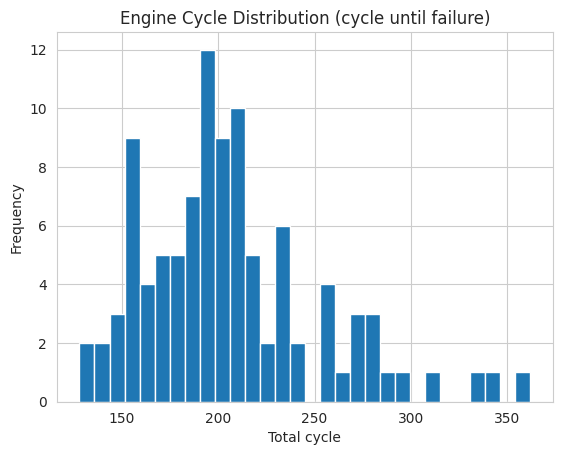

In [8]:
# Engine Cycle Distribution

print("Amount of unit engine (train):", df_train['unit_number'].nunique())
df_train.groupby('unit_number')['time_cycles'].max().plot(
    kind='hist', bins=30, title='Engine Cycle Distribution (cycle until failure)'
)
plt.xlabel('Total cycle')
plt.show()

In [9]:
# Check the constant sensor (will be dropped if not informative)

sensor_cols_all = [f'sensor_{i}' for i in range(1,22)]
constant_sensors = [c for c in sensor_cols_all if df_train[c].std() < 0.0001]
print("Constant Sensor (drop):", constant_sensors)

active_sensors = [c for c in sensor_cols_all if c not in constant_sensors]
print("Active Sensor (use)", len(active_sensors))

Constant Sensor (drop): ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Active Sensor (use) 15


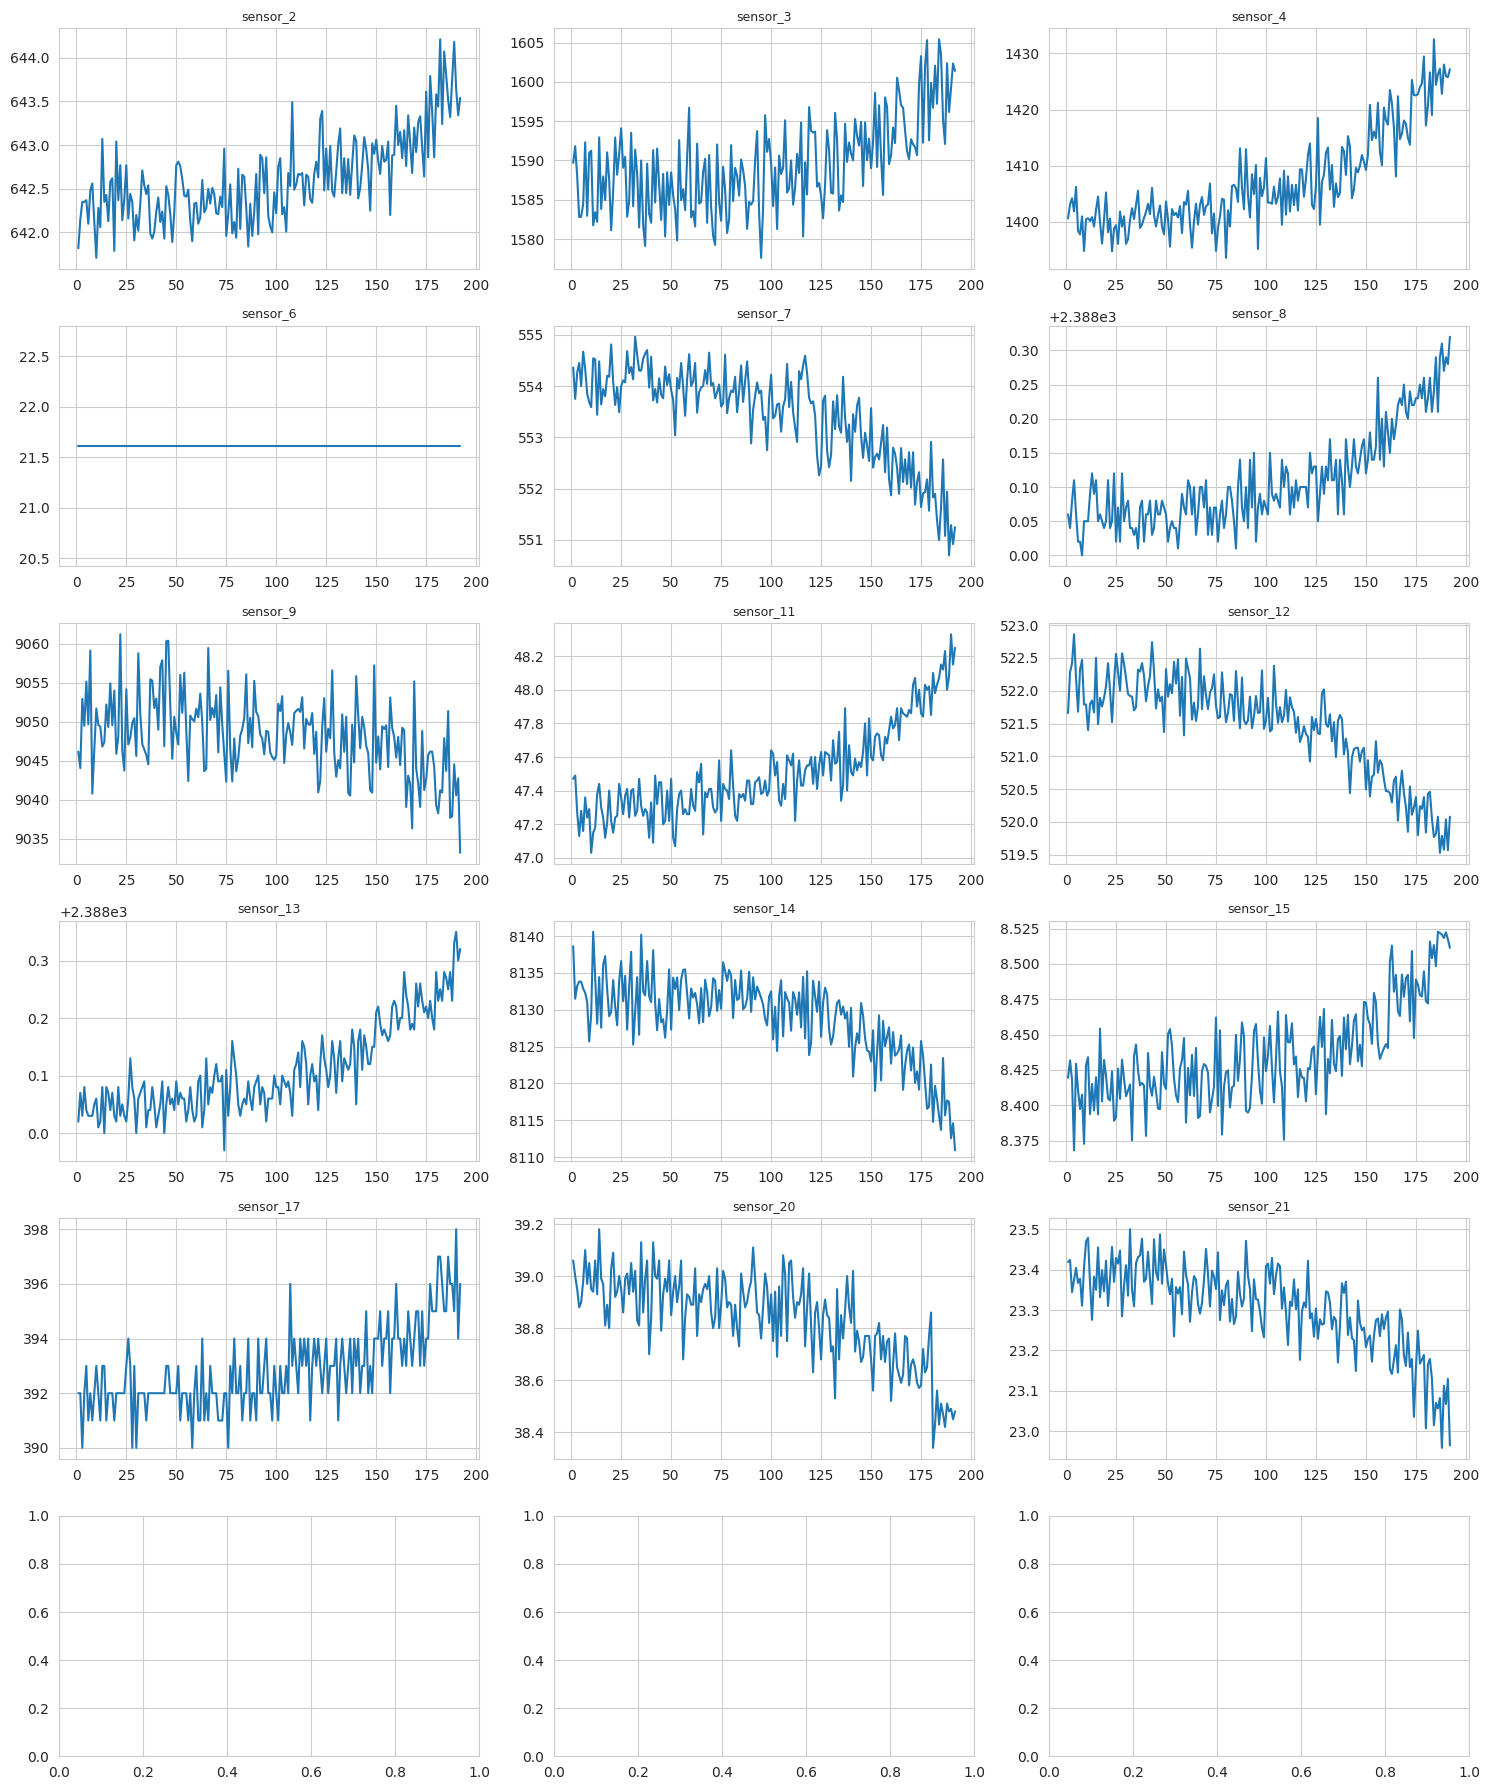

In [10]:
# Visualize the trend sensor for 1 example unit

unit1 = df_train[df_train['unit_number'] == 1]
fig, axes = plt.subplots(len(active_sensors)//3 + 1, 3, figsize=(15, 18))
axes = axes.flatten()
for i, col in enumerate(active_sensors):
    axes[i].plot(unit1['time_cycles'], unit1[col])
    axes[i].set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

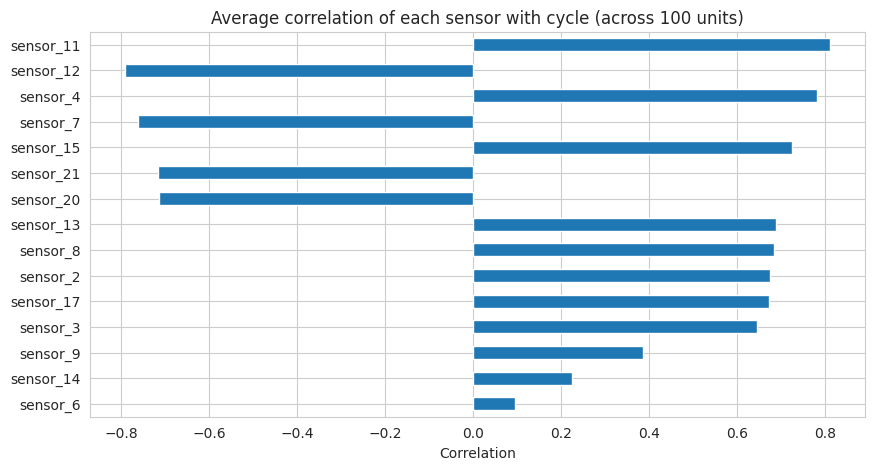

sensor_11    0.810601
sensor_12   -0.789662
sensor_4     0.781614
sensor_7    -0.761514
sensor_15    0.724844
sensor_21   -0.716710
sensor_20   -0.714120
sensor_13    0.687316
sensor_8     0.683526
sensor_2     0.675276
sensor_17    0.673123
sensor_3     0.643950
sensor_9     0.385955
sensor_14    0.223504
sensor_6     0.095414
dtype: float64


In [11]:
# to get more robust - check the correlation on each sensor with cycle (avg across whole unit)

correlations = df_train.groupby('unit_number').apply(
    lambda x: x[active_sensors].corrwith(x['time_cycles'])
)

mean_corr = correlations.mean().sort_values(key=abs, ascending=False)

plt.figure(figsize=(10,5))
mean_corr.plot(kind='barh')
plt.title('Average correlation of each sensor with cycle (across 100 units)')
plt.xlabel('Correlation')
plt.gca().invert_yaxis()
plt.show()

print(mean_corr)

Read me:

**The top 4 most informative sensors (sensor_11, 12, 4, 7)** are all directly related to **pressure and fuel flow in the HPC area and downstream (LPT)**. This aligns perfectly with the FD001 dataset's fault mode—HPC degradation—meaning the correlation analysis results empirically validate domain knowledge: the sensors physically most relevant to the faulty component indeed emerge as the most statistically predictive ones.

Regarding sensor_6 (P15, bypass duct pressure)—although it passed the "non-constant" filter, its correlation is very weak (0.095). This makes sense because P15 is measured in the bypass duct rather than the airflow path passing through the HPC; physically, it is not significantly affected by HPC degradation.

# Feature Engineering

Count the RUL for training data

In [12]:
# Count the RUL for training data

max_cycle = df_train.groupby('unit_number')['time_cycles'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_cycle']
df_train = df_train.merge(max_cycle, on='unit_number')
df_train['RUL'] = df_train['max_cycle'] - df_train['time_cycles']
df_train.drop('max_cycle', axis=1, inplace=True)

# Piecewise RUL (cap in 125, literatur standard of CMAPSS)

RUL_CAP = 125
df_train['RUL'] = df_train['RUL'].clip(upper=RUL_CAP)
df_train.head()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


In [13]:
# Normalize
feature_cols = ['op_setting_1','op_setting_2','op_setting_3'] + active_sensors

scaler = MinMaxScaler()
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_test[feature_cols]  = scaler.transform(df_test[feature_cols])

Rolling features, to catch the trend not solely the value

In [14]:
window = 5

def add_rolling(df, cols, window):
    df = df.sort_values(['unit_number','time_cycles']).copy()
    for col in cols:
        df[f'{col}_rollmean'] = df.groupby('unit_number')[col].transform(
            lambda x: x.rolling(window, min_periods=1).mean())
    return df

df_train = add_rolling(df_train, active_sensors, window)
df_test  = add_rolling(df_test, active_sensors, window)

final_features = feature_cols + [f'{c}_rollmean' for c in active_sensors]
print("Total final feature:", len(final_features))

Total final feature: 33


In [15]:
print(final_features)

['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'sensor_2_rollmean', 'sensor_3_rollmean', 'sensor_4_rollmean', 'sensor_6_rollmean', 'sensor_7_rollmean', 'sensor_8_rollmean', 'sensor_9_rollmean', 'sensor_11_rollmean', 'sensor_12_rollmean', 'sensor_13_rollmean', 'sensor_14_rollmean', 'sensor_15_rollmean', 'sensor_17_rollmean', 'sensor_20_rollmean', 'sensor_21_rollmean']


In [16]:
# see the result for 1 unit

sample = df_train[df_train['unit_number'] == 1][['time_cycles', 'sensor_11', 'sensor_11_rollmean']].head(10)
print(sample)

   time_cycles  sensor_11  sensor_11_rollmean
0            1   0.369048            0.369048
1            2   0.380952            0.375000
2            3   0.250000            0.333333
3            4   0.166667            0.291667
4            5   0.255952            0.284524
5            6   0.184524            0.247619
6            7   0.303571            0.232143
7            8   0.232143            0.228571
8            9   0.261905            0.247619
9           10   0.107143            0.217857


# Modeling (Random Forest)

In [17]:
# Split data for training dan validation

from sklearn.model_selection import train_test_split

X = df_train[final_features]
y = df_train['RUL']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (16504, 33)
X_val shape: (4127, 33)


In [18]:
# Train Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

Evalution in Validation Set

In [19]:
# Evaluation in validation set

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred_val = rf_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae = mean_absolute_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.3f}")

RMSE: 16.81
MAE: 11.80
R²: 0.834


Feature Importance

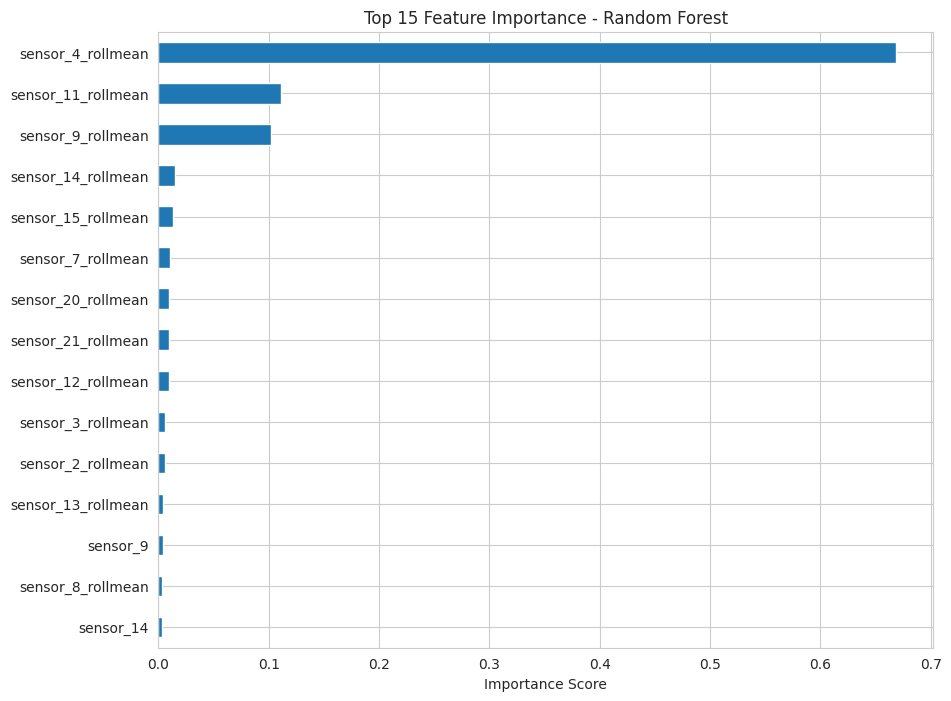

sensor_4_rollmean     0.668983
sensor_11_rollmean    0.111322
sensor_9_rollmean     0.102542
sensor_14_rollmean    0.015224
sensor_15_rollmean    0.013474
sensor_7_rollmean     0.010361
sensor_20_rollmean    0.009985
sensor_21_rollmean    0.009877
sensor_12_rollmean    0.009849
sensor_3_rollmean     0.006101
sensor_2_rollmean     0.006066
sensor_13_rollmean    0.004651
sensor_9              0.004623
sensor_8_rollmean     0.003445
sensor_14             0.002933
dtype: float64


In [20]:
# Feature importance
importance = pd.Series(rf_model.feature_importances_, index=final_features).sort_values(ascending=False)

plt.figure(figsize=(10,8))
importance.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.show()

print(importance.head(15))

Prediction to Test Dataset

In [21]:
df_test_last = df_test.groupby('unit_number').last().reset_index()  # take last cycle on each unit

X_test = df_test_last[final_features]
y_test_true = df_rul['RUL'].values

y_test_pred = rf_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
mae_test = mean_absolute_error(y_test_true, y_test_pred)

print(f"TEST SET - RMSE: {rmse_test:.2f}")
print(f"TEST SET - MAE: {mae_test:.2f}")

TEST SET - RMSE: 18.99
TEST SET - MAE: 13.69


Visualization

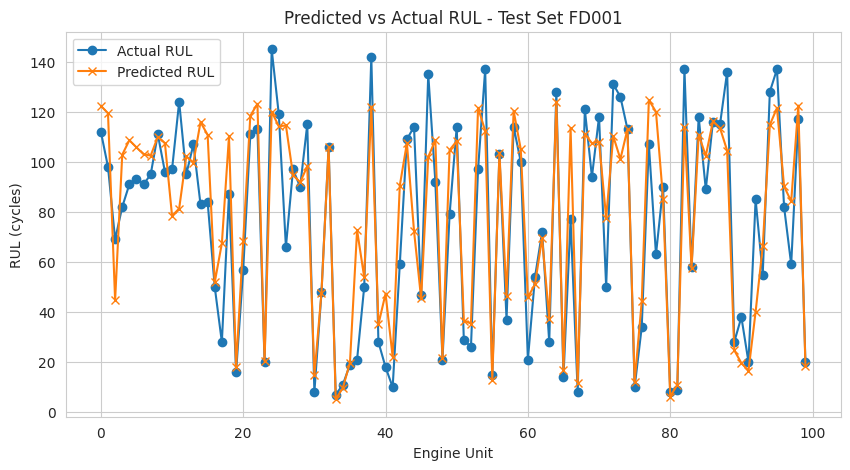

In [22]:
# Plot predicted vs actual

plt.figure(figsize=(10,5))
plt.plot(y_test_true, label='Actual RUL', marker='o')
plt.plot(y_test_pred, label='Predicted RUL', marker='x')
plt.legend()
plt.title('Predicted vs Actual RUL - Test Set FD001')
plt.xlabel('Engine Unit')
plt.ylabel('RUL (cycles)')
plt.show()

Insight:
Model performs better at predicting near-failure conditions (low RUL) compared to healthy conditions (high RUL), which aligns with the piecewise RUL labeling strategy, this is actually desirable since maintenance decisions are most critical when RUL is low.

# CMAPSS Scoring Function

d negative = prediction too low (early warning, safer)
d positive = prediction too high (delayed warning, more dangerous)

In [23]:
# CMAPSS Asymmetric Scoring Function

def cmapss_score(y_true, y_pred):
    d = y_pred - y_true

    score = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
    return np.sum(score)

score = cmapss_score(y_test_true, y_test_pred)
print(f"CMAPSS Score: {score:.2f}")

CMAPSS Score: 1066.13


Save Model & Artifacts

In [24]:
# save model, scaler, dan feature list

import joblib
import json
import os

os.makedirs('models', exist_ok=True)

joblib.dump(rf_model, 'models/rf_rul_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

with open('models/feature_cols.json', 'w') as f:
    json.dump(final_features, f)

with open('models/active_sensors.json', 'w') as f:
    json.dump(active_sensors, f)

print("saved")

saved


In [25]:
# Download model folder

from google.colab import files
!zip -r models.zip models/
files.download('models.zip')

  adding: models/ (stored 0%)
  adding: models/active_sensors.json (deflated 69%)
  adding: models/feature_cols.json (deflated 78%)
  adding: models/scaler.pkl (deflated 38%)
  adding: models/rf_rul_model.pkl (deflated 74%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Modeling 2 (LSTM)

Sequence Length of Data

In [26]:
# setup sequence length

sequence_length = 30

def gen_sequences(df, seq_len, feature_cols, target_col='RUL'):
    sequences, labels = [], []
    for unit in df['unit_number'].unique():
        unit_df = df[df['unit_number'] == unit].sort_values('time_cycles')
        data = unit_df[feature_cols].values
        target = unit_df[target_col].values

        # should be skip if this unit data  is shorter than sequence_length
        if len(data) < seq_len:
            continue

        for i in range(len(data) - seq_len + 1):
            sequences.append(data[i:i+seq_len])
            labels.append(target[i+seq_len-1])  # RUL at the end of window

    return np.array(sequences), np.array(labels)

X_seq, y_seq = gen_sequences(df_train, sequence_length, final_features)

print("Shape X_seq:", X_seq.shape)
print("Shape y_seq:", y_seq.shape)

Shape X_seq: (17731, 30, 33)
Shape y_seq: (17731,)


Split train and validation

In [27]:
from sklearn.model_selection import train_test_split

X_train_seq, X_val_seq, y_train_seq, y_val_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

print("Train:", X_train_seq.shape, "Val:", X_val_seq.shape)

Train: (14184, 30, 33) Val: (3547, 30, 33)


Install & Import PyTorch

In [28]:
# Import PyTorch

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Check whether GPU is available

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("using the device of:", device)

using the device of: cuda


Create Dataset & DataLoader

In [29]:
# PyTorch Dataset class

class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = RULDataset(X_train_seq, y_train_seq)
val_dataset = RULDataset(X_val_seq, y_val_seq)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

Build the LSTM Architecture

In [34]:
# define the LSTM Model

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        out = out[:, -1, :]  # take the output in the last timestep
        out = self.fc(out)
        return out.squeeze()

input_size = X_train_seq.shape[2]
model = LSTMModel(input_size=input_size).to(device)
print(model)

LSTMModel(
  (lstm): LSTM(33, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


Training Loop

In [35]:
# training

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 60
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_val_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.2f} - Val Loss: {avg_val_loss:.2f}")

Epoch 1/60 - Train Loss: 6621.00 - Val Loss: 5437.82
Epoch 2/60 - Train Loss: 4809.10 - Val Loss: 4047.17
Epoch 3/60 - Train Loss: 3631.90 - Val Loss: 3104.52
Epoch 4/60 - Train Loss: 2845.56 - Val Loss: 2494.33
Epoch 5/60 - Train Loss: 2347.80 - Val Loss: 2124.35
Epoch 6/60 - Train Loss: 2050.53 - Val Loss: 1915.49
Epoch 7/60 - Train Loss: 1888.21 - Val Loss: 1810.71
Epoch 8/60 - Train Loss: 1807.50 - Val Loss: 1762.66
Epoch 9/60 - Train Loss: 1771.32 - Val Loss: 1744.54
Epoch 10/60 - Train Loss: 1757.39 - Val Loss: 1738.89
Epoch 11/60 - Train Loss: 1752.93 - Val Loss: 1737.82
Epoch 12/60 - Train Loss: 1751.14 - Val Loss: 1737.98
Epoch 13/60 - Train Loss: 1751.03 - Val Loss: 1738.23
Epoch 14/60 - Train Loss: 1750.64 - Val Loss: 1738.53
Epoch 15/60 - Train Loss: 1750.00 - Val Loss: 1738.76
Epoch 16/60 - Train Loss: 1751.55 - Val Loss: 1738.40
Epoch 17/60 - Train Loss: 1750.91 - Val Loss: 1738.44
Epoch 18/60 - Train Loss: 1750.66 - Val Loss: 1738.58
Epoch 19/60 - Train Loss: 1750.92 - V

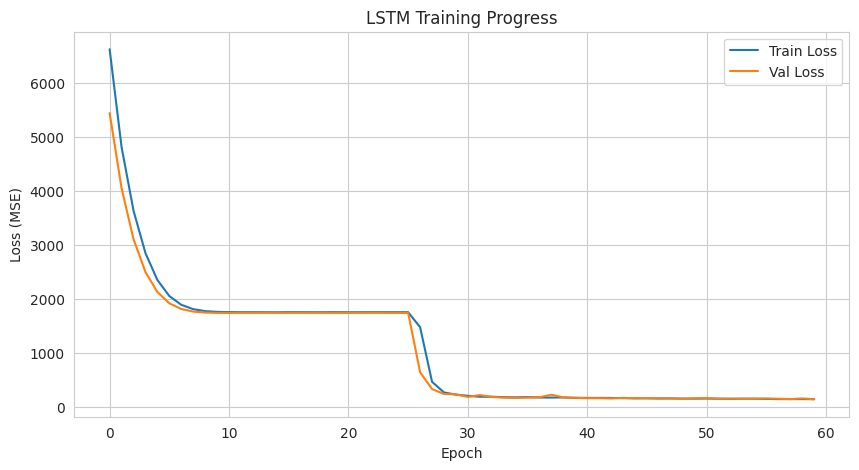

In [36]:
# visualize the training

plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('LSTM Training Progress')
plt.show()

Evaluate to test set

In [38]:
# predict to test set (LSTM)

# 1. generate sequence for test set (the last 30 cycle per unit)
def gen_test_sequences(df, seq_len, feature_cols):
    sequences = []
    unit_ids = []
    for unit in df['unit_number'].unique():
        unit_df = df[df['unit_number'] == unit].sort_values('time_cycles')
        data = unit_df[feature_cols].values

        if len(data) < seq_len:
            # if data less than 30, padding in the beginning with first cycle will be repeated
            pad_length = seq_len - len(data)
            padding = np.tile(data[0], (pad_length, 1))
            data = np.vstack([padding, data])

        # take the last 30 cyc
        sequences.append(data[-seq_len:])
        unit_ids.append(unit)

    return np.array(sequences), unit_ids

X_test_seq, test_unit_ids = gen_test_sequences(df_test, sequence_length, final_features)
print("Shape X_test_seq:", X_test_seq.shape)

Shape X_test_seq: (100, 30, 33)


Predict

In [40]:
# predict
model.eval()
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32).to(device)

with torch.no_grad():
    y_test_pred_lstm = model(X_test_tensor).cpu().numpy()

print("prediction amount:", len(y_test_pred_lstm))

prediction amount: 100


In [41]:
# evaluate (RMSE, MAE, CMAPSS Score)
y_test_true_lstm = df_rul['RUL'].values  # ensure the sequence unit is same

rmse_lstm = np.sqrt(mean_squared_error(y_test_true_lstm, y_test_pred_lstm))
mae_lstm = mean_absolute_error(y_test_true_lstm, y_test_pred_lstm)
score_lstm = cmapss_score(y_test_true_lstm, y_test_pred_lstm)

print(f"LSTM - RMSE: {rmse_lstm:.2f}")
print(f"LSTM - MAE: {mae_lstm:.2f}")
print(f"LSTM - CMAPSS Score: {score_lstm:.2f}")

print("\n--- Perbandingan ---")
print(f"Random Forest - RMSE: 18.99, MAE: 13.69, CMAPSS Score: 1066.13")
print(f"LSTM          - RMSE: {rmse_lstm:.2f}, MAE: {mae_lstm:.2f}, CMAPSS Score: {score_lstm:.2f}")

LSTM - RMSE: 14.70
LSTM - MAE: 10.59
LSTM - CMAPSS Score: 467.27

--- Perbandingan ---
Random Forest - RMSE: 18.99, MAE: 13.69, CMAPSS Score: 1066.13
LSTM          - RMSE: 14.70, MAE: 10.59, CMAPSS Score: 467.27


In [42]:
print(test_unit_ids[:10])

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


While Random Forest achieved reasonable baseline performance (RMSE: 18.99, CMAPSS Score: 1066.13), the LSTM model (leveraging full 30-cycle temporal sequences rather than static rolling-window summaries), achieved a 22.6% improvement in RMSE/MAE and a 56.2% improvement in CMAPSS score. The larger improvement in CMAPSS score specifically indicates the LSTM is substantially better at avoiding late (dangerous) RUL predictions, which is the more safety-critical failure mode in aviation maintenance contexts

# Plot and Save

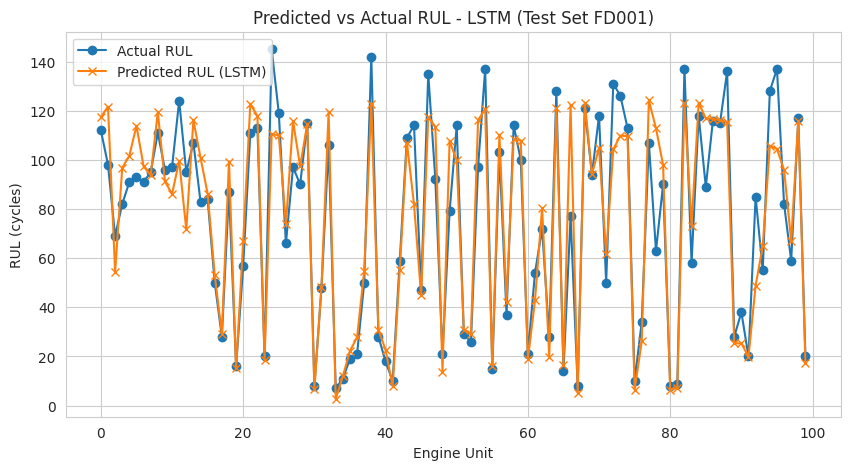

In [43]:
# Plot predicted vs actual (LSTM)
plt.figure(figsize=(10,5))
plt.plot(y_test_true_lstm, label='Actual RUL', marker='o')
plt.plot(y_test_pred_lstm, label='Predicted RUL (LSTM)', marker='x')
plt.legend()
plt.title('Predicted vs Actual RUL - LSTM (Test Set FD001)')
plt.xlabel('Engine Unit')
plt.ylabel('RUL (cycles)')
plt.show()

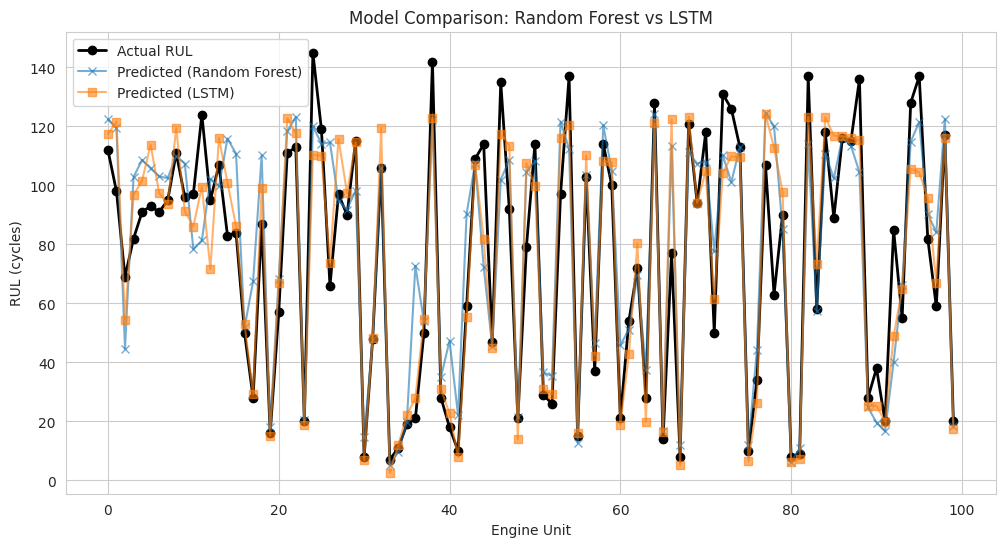

In [44]:
# Plot the comparison of RF vs LSTM

plt.figure(figsize=(12,6))
plt.plot(y_test_true_lstm, label='Actual RUL', marker='o', linewidth=2, color='black')
plt.plot(y_test_pred, label='Predicted (Random Forest)', marker='x', alpha=0.6)
plt.plot(y_test_pred_lstm, label='Predicted (LSTM)', marker='s', alpha=0.6)
plt.legend()
plt.title('Model Comparison: Random Forest vs LSTM')
plt.xlabel('Engine Unit')
plt.ylabel('RUL (cycles)')
plt.show()

Create summary table

In [45]:
# Summary table
summary = pd.DataFrame({
    'Model': ['Random Forest', 'LSTM'],
    'RMSE': [18.99, rmse_lstm],
    'MAE': [13.69, mae_lstm],
    'CMAPSS Score': [1066.13, score_lstm]
})
print(summary)
summary.to_csv('models/model_comparison.csv', index=False)

           Model       RMSE        MAE  CMAPSS Score
0  Random Forest  18.990000  13.690000   1066.130000
1           LSTM  14.696651  10.592096    467.268859


In [47]:
# save all artifacts

import joblib
import json
import os

os.makedirs('models', exist_ok=True)

# Random Forest
joblib.dump(rf_model, 'models/rf_rul_model.pkl')

# LSTM
torch.save(model.state_dict(), 'models/lstm_rul_model.pth')

# Scaler (for normalize data)
joblib.dump(scaler, 'models/scaler.pkl')

# Feature list & config
with open('models/feature_cols.json', 'w') as f:
    json.dump(final_features, f)

with open('models/active_sensors.json', 'w') as f:
    json.dump(active_sensors, f)

config = {
    'sequence_length': sequence_length,
    'input_size': input_size,
    'hidden_size': 64,
    'num_layers': 2,
    'rul_cap': 125
}
with open('models/lstm_config.json', 'w') as f:
    json.dump(config, f)

print("everyhting is saved")
print(os.listdir('models'))

everyhting is saved
['lstm_config.json', 'active_sensors.json', 'lstm_rul_model.pth', 'model_comparison.csv', 'feature_cols.json', 'scaler.pkl', 'rf_rul_model.pkl']


In [48]:
#zip and download
!zip -r models.zip models/
from google.colab import files
files.download('models.zip')

updating: models/ (stored 0%)
updating: models/active_sensors.json (deflated 69%)
updating: models/feature_cols.json (deflated 78%)
updating: models/scaler.pkl (deflated 38%)
updating: models/rf_rul_model.pkl (deflated 74%)
  adding: models/lstm_config.json (deflated 14%)
  adding: models/lstm_rul_model.pth (deflated 8%)
  adding: models/model_comparison.csv (deflated 11%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>